In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [2]:
# Generating the data for analysis
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [3]:
s = (pd.Series(L).value_counts() / pd.Series(L).value_counts().sum()).sort_index() # Normalizing and sorting
np.cumsum(s)

2     0.0284
3     0.0833
4     0.1644
5     0.2772
6     0.4178
7     0.5913
8     0.7317
9     0.8419
10    0.9197
11    0.9721
12    1.0000
Name: count, dtype: float64

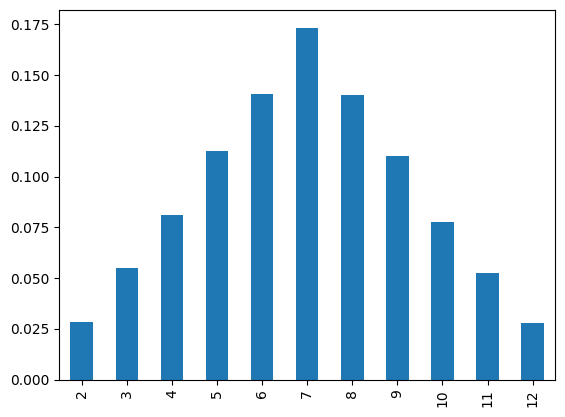

In [4]:
s.plot(kind = 'bar')
plt.show()

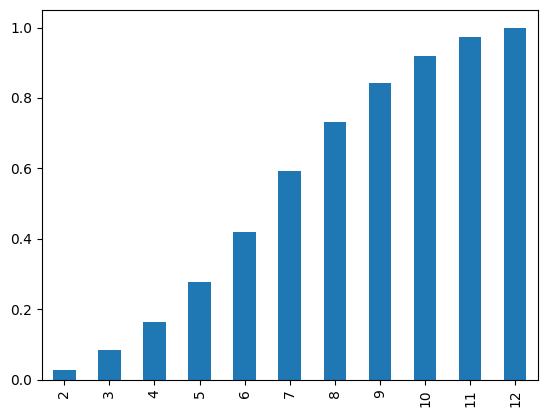

In [5]:
np.cumsum(s).plot(kind='bar')
plt.show()

---

In [6]:
# Generating normally distributed data
sample = np.random.normal(loc=50, scale=5, size=1000)
sample.mean()

np.float64(49.719295128585834)

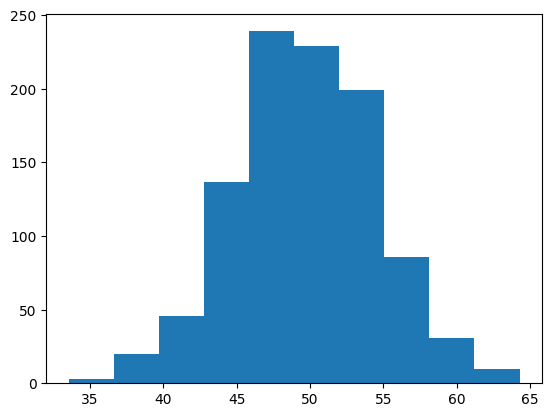

In [7]:
# Plot histogram to understand the distribution of data
plt.hist(sample, bins=10)
plt.show()

#### *`Parameteric Approach`*

In [8]:
# Parameters - Calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

# Fit the distribution with the above parameters
dist = norm(60, 12)

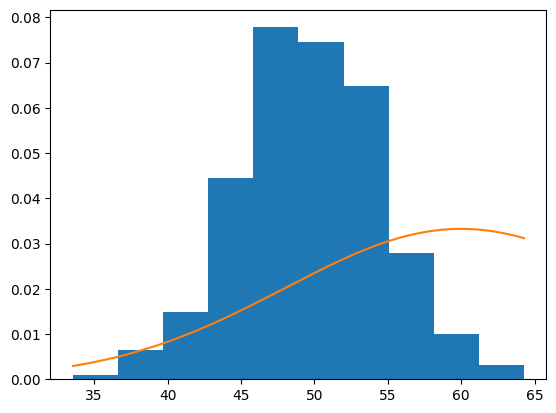

In [9]:
# Generating sorted values and its probabilities
values = np.linspace(sample.min(),sample.max(),1000)
probabilities = [dist.pdf(value) for value in values]

# plot the histogram and pdf
plt.hist(sample, bins=10, density=True)
plt.plot(values, probabilities)
plt.show()

#### *`Non-Parametric Approach`*

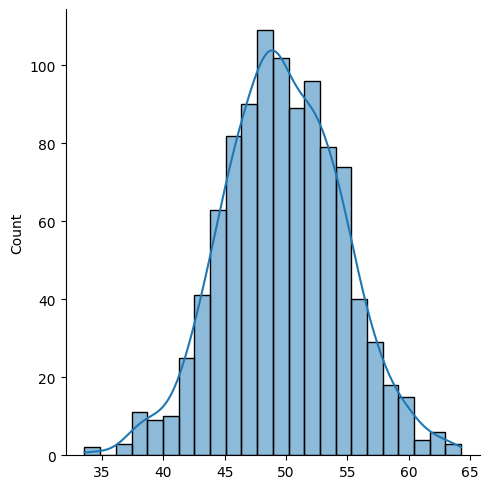

In [10]:
sns.displot(sample, kde = True)
plt.show()

---

In [11]:
# Generate a sample
sample1 = np.random.normal(loc=20, scale=5, size=300)
sample2 = np.random.normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [12]:
sample[:5]

array([22.51466133, 24.10169445, 21.92733905, 21.43150227, 15.33505404])

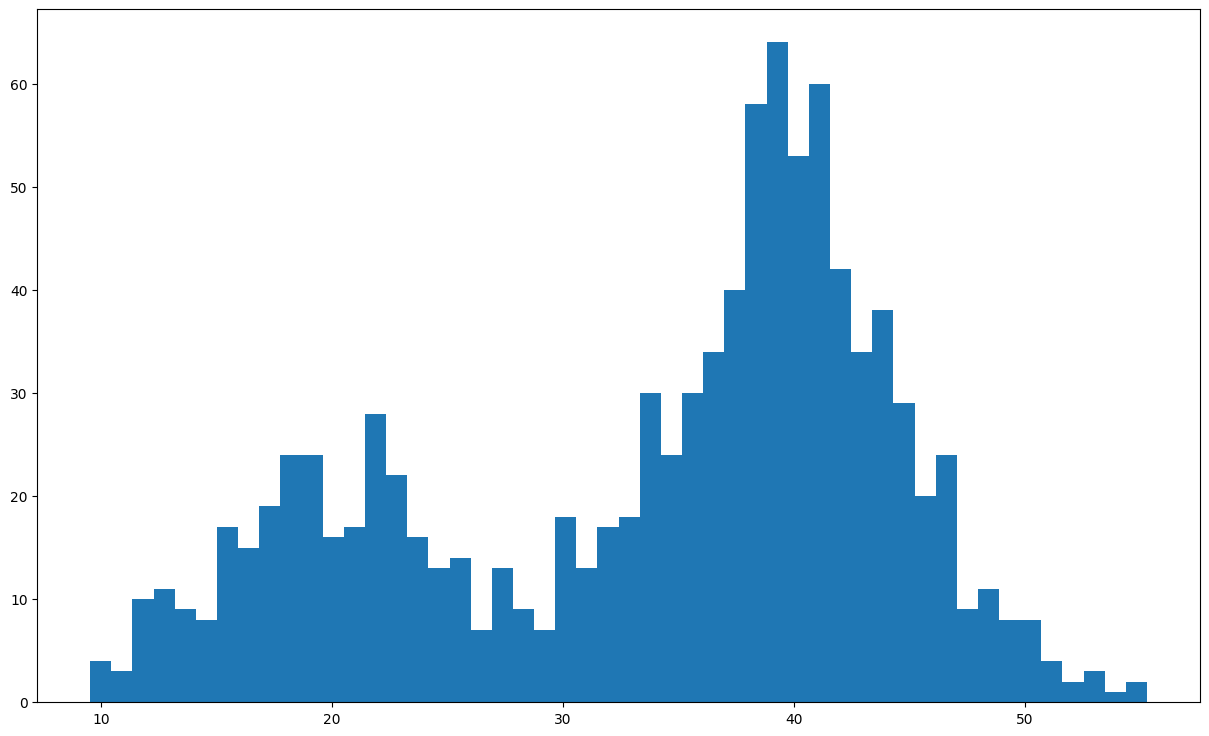

In [13]:
# Plot histogram bins=50
plt.figure(figsize = (15, 9))
plt.hist(sample, bins=50)
plt.show()

In [14]:
# Building model
from sklearn.neighbors import KernelDensity
model = KernelDensity(bandwidth=5, kernel='gaussian')

# Convert data to a 2D array
sample = sample.reshape((len(sample), 1))

# Model Training
model.fit(sample)

,bandwidth,5
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [15]:
values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape((len(values), 1))

probabilities = model.score_samples(values) # Bydefault these values are log scaled
probabilities = np.exp(probabilities)

*`score_samples(values)` returns the log-density estimate of the input samples values. This is because the `score_samples()` method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.*

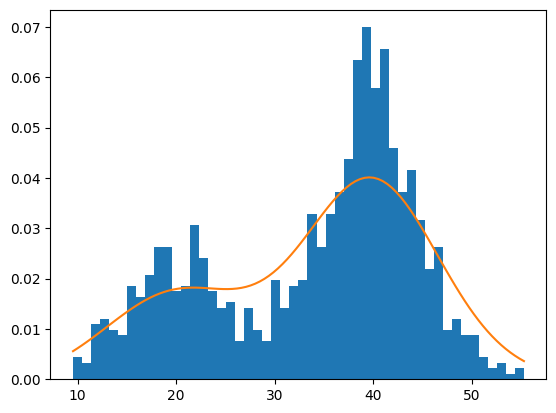

In [16]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

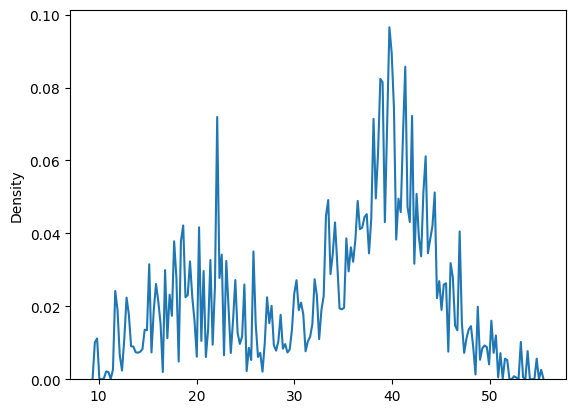

In [17]:
sns.kdeplot(sample.reshape(1000), bw_adjust=0.02) # Some how adjut the bandwidth
plt.show()

#### `Practical Use Case`

In [18]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


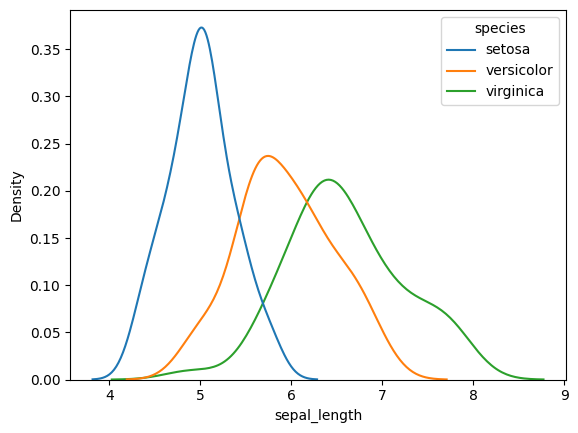

In [19]:
sns.kdeplot(data=df, x='sepal_length', hue='species')
plt.show()

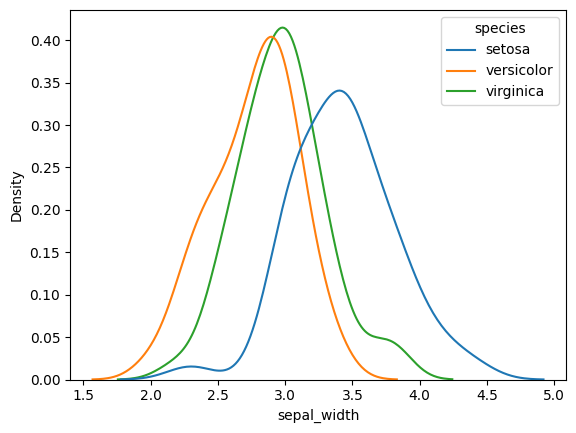

In [20]:
sns.kdeplot(data=df,x='sepal_width',hue='species')
plt.show()

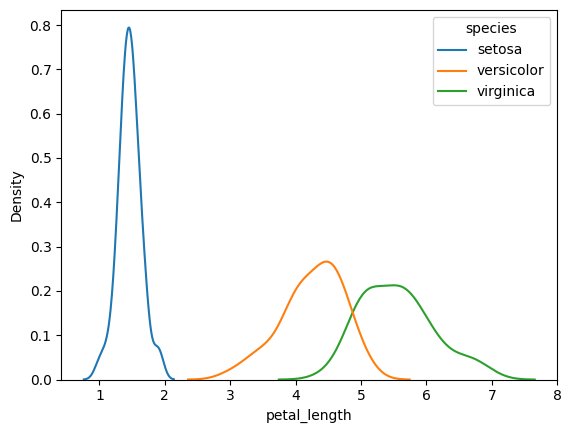

In [21]:
sns.kdeplot(data=df,x='petal_length', hue='species')
plt.show()

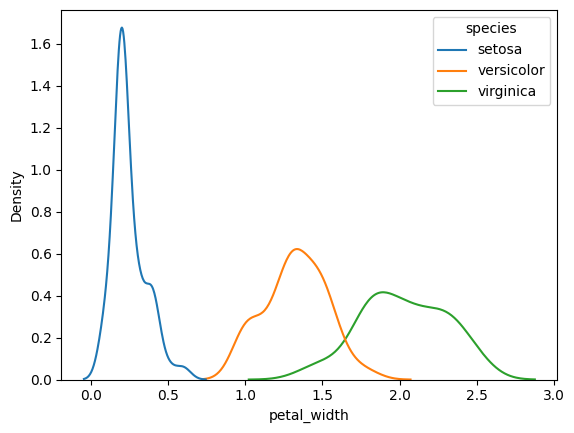

In [22]:
sns.kdeplot(data=df,x='petal_width', hue='species')
plt.show()

*`petal_length` and `petal_width` are important features who seperates `setosa` flowers*

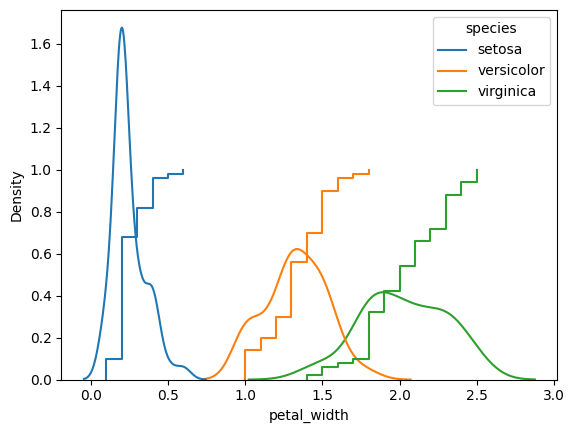

In [23]:
sns.kdeplot(data=df, x = 'petal_width', hue = 'species')
sns.ecdfplot(data=df,x='petal_width', hue='species')
plt.show()

---

In [24]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


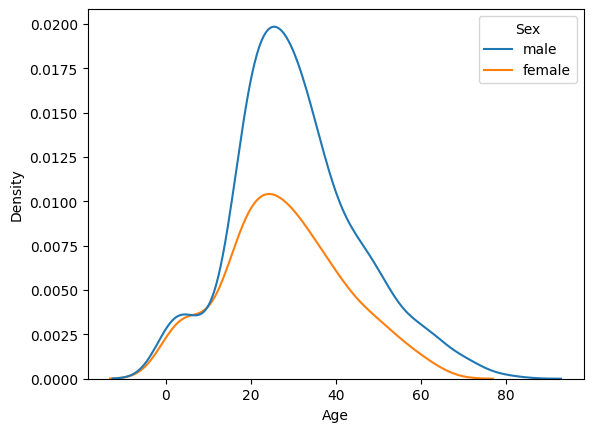

In [25]:
sns.kdeplot(data=titanic, x='Age', hue='Sex')
plt.show()

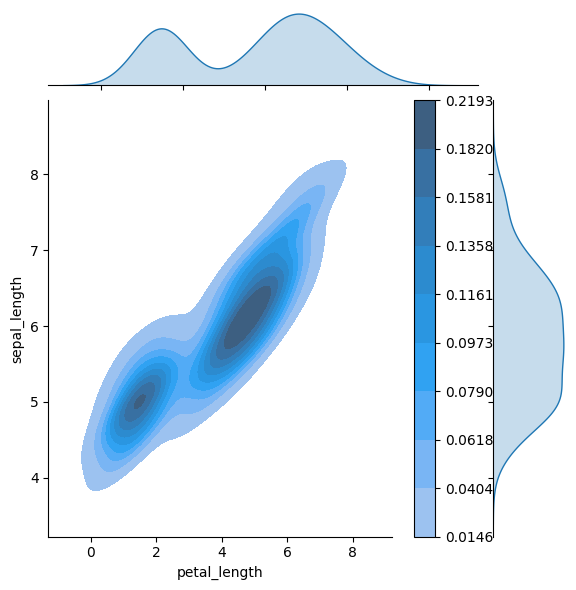

In [26]:
sns.jointplot(data=df, x="petal_length", y="sepal_length", kind="kde", fill=True, cbar=True)
plt.show()

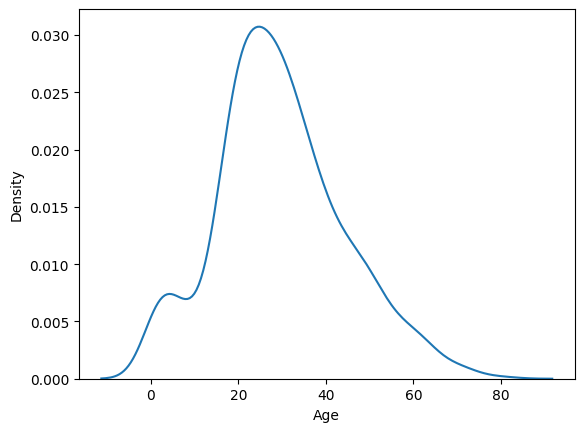

In [27]:
sns.kdeplot(titanic['Age'])
plt.show()

In [28]:
# Standardization
x = (titanic['Age'] - titanic['Age'].mean())/titanic['Age'].std()

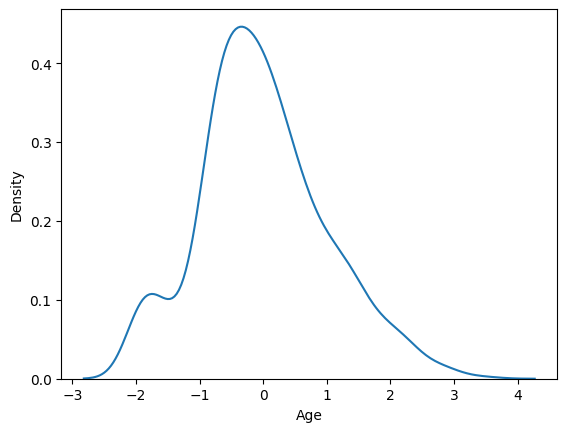

In [29]:
sns.kdeplot(x)
plt.show()

In [30]:
titanic['Age'].skew()

np.float64(0.38910778230082704)

you can manually calculate it computing the fourth central moment divided by the square of the variance:

$$ \text{Kurtosis} = \frac{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^4}{\left( \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2 \right)^2} $$

In [ ]:
# Finding the kurtosis using scipy
from scipy.stats import kurtosis

kurtosis(titanic.loc[:, 'Age'].dropna(), fisher=True) - 3 # If Fisher's definition is used, then 3.0 is subtracted from the result to give 0.0 for a normal distribution.

np.float64(-2.8313634277571396)

In [ ]:
# Finding the kurtosis using pandas
titanic.loc[:, 'Age'].kurtosis() - 3 # Pandas Function

np.float64(-2.8217258463578965)

In [31]:
titanic['Age'].mean() + 3*titanic['Age'].std()

np.float64(73.27860964406094)

In [32]:
titanic['Age'].mean() - 3*titanic['Age'].std()

np.float64(-13.880374349943303)

In [33]:
# Outliers
titanic[titanic['Age'] > 73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


Kurtosis primarily measures **tailedness**, not peakedness.

While it is a common misconception that high kurtosis means a "sharper" or "taller" peak, the statistical definition focuses entirely on the probability mass in the **tails** of the distribution (the outliers).

Here is the breakdown of both concepts in relation to kurtosis:

### 1. Tailedness (The Correct Interpretation)
Kurtosis quantifies how much the data is concentrated in the tails `relative to a normal distribution`.
*   **High Kurtosis (Leptokurtic):** Indicates **heavy tails**. This means there is a higher probability of extreme values (outliers) than in a normal distribution. The data has more "extreme" deviations.
*   **Low Kurtosis (Platykurtic):** Indicates **light tails**. Extreme values are rare. The data clusters tightly around the mean with few outliers.
*   **Mesokurtic:** Similar to a normal distribution (kurtosis = 3, or excess kurtosis = 0).

> **Key Insight:** If you have a distribution with high kurtosis, it doesn't necessarily have a high peak; it just has more data far away from the center.

### 2. Peakedness (The Misconception)
The idea that kurtosis measures "peakedness" is largely a myth that persists in introductory statistics.
*   You can have a distribution with a very **flat** top but extremely heavy tails, resulting in **high kurtosis**.
*   Conversely, you can have a distribution with a very **sharp, tall** peak but very light tails, resulting in **low kurtosis**.
*   Mathematically, the peak contributes very little to the kurtosis calculation because the formula weights deviations by the **fourth power** ($ (x - \mu)^4 $). Points far from the mean (the tails) dominate the calculation, while points near the mean (the peak) have a negligible effect.

### Summary Comparison

| Feature | High Kurtosis | Low Kurtosis |
| :--- | :--- | :--- |
| **Tails** | **Heavy/Long** (More outliers) | **Light/Short** (Fewer outliers) |
| **Risk** | Higher risk of extreme events | Lower risk of extreme events |
| **Peak Shape** | Can be sharp, flat, or even bimodal | Can be sharp, flat, or uniform |
| **Primary Meaning** | **Tailedness** | **Tailedness** |

**Conclusion:** When you see a high kurtosis value, think **"outliers"** and **"extreme events,"** not "spiky peak." The peak shape is incidental, while the tail behavior is the defining characteristic.